In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BIDS_DIR = Path('/data/ds-valuecapture')
subjects = [1, 2]
sessions = [1, 2]

In [2]:
dfs = []

for sub in subjects:
    for ses in sessions:
        func_dir = BIDS_DIR / f'sub-{sub:02d}' / f'ses-{ses}' / 'func'
        for tsv in sorted(func_dir.glob(f'sub-{sub:02d}_ses-{ses}_task-valuecapture_run-*_events.tsv')):
            run = int(tsv.stem.split('run-')[1].split('_')[0])
            df = pd.read_csv(tsv, sep='\t')
            df['subject'] = sub
            df['session'] = ses
            df['run'] = run
            dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(dfs)} runs, {df.subject.nunique()} subjects')

Loaded 32 runs, 2 subjects


In [3]:
# One row per trial: iti1 phase has rt and correct filled in
trials = df[df['event_type'] == 'iti1'].copy()

def condition(row):
    if not row['distractor_present']:
        return 'absent'
    return f'rank-{int(row["value_rank"])}'

trials['condition'] = trials.apply(condition, axis=1)
trials['rt_ms'] = trials['rt'] * 1000

print(trials['condition'].value_counts())

condition
rank-1    320
rank-2    320
rank-0    320
absent    320
Name: count, dtype: int64


In [4]:
CONDITION_ORDER = ['absent', 'rank-0', 'rank-1', 'rank-2']

grp = ['subject', 'session', 'condition']
mean_rt  = trials[trials['correct'] == True].groupby(grp)['rt_ms'].mean().rename('mean_rt')
accuracy = trials.groupby(grp)['correct'].mean().rename('accuracy')

summary = pd.concat([mean_rt, accuracy], axis=1).reset_index()
summary['condition'] = pd.Categorical(summary['condition'], categories=CONDITION_ORDER, ordered=True)
summary = summary.sort_values(['subject', 'session', 'condition'])
summary

,subject,session,condition,mean_rt,accuracy
0,1,1,absent,1084.234655,0.769231
1,1,1,rank-0,1064.396989,0.805195
2,1,1,rank-1,1129.985619,0.821918
3,1,1,rank-2,1090.667339,0.666667
4,1,2,absent,886.483449,0.8125
5,1,2,rank-0,900.158506,0.810127
6,1,2,rank-1,882.455233,0.820513
7,1,2,rank-2,929.043517,0.8375
8,2,1,absent,845.990983,0.925
9,2,1,rank-0,920.441784,0.924051


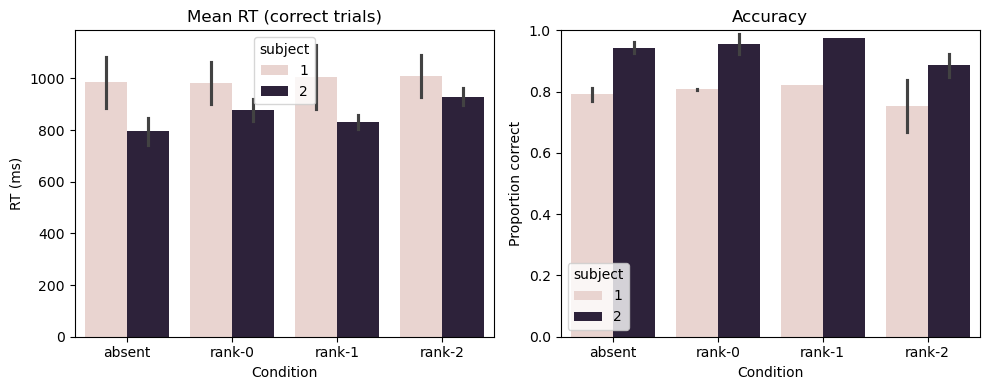

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=summary, x='condition', y='mean_rt', hue='subject',
            order=CONDITION_ORDER, ax=axes[0])
axes[0].set_title('Mean RT (correct trials)')
axes[0].set_ylabel('RT (ms)')
axes[0].set_xlabel('Condition')

sns.barplot(data=summary, x='condition', y='accuracy', hue='subject',
            order=CONDITION_ORDER, ax=axes[1])
axes[1].set_title('Accuracy')
axes[1].set_ylabel('Proportion correct')
axes[1].set_xlabel('Condition')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [6]:
# Grand mean across sessions
grand = summary.groupby(['subject', 'condition'])[['mean_rt', 'accuracy']].mean().round(1)
grand

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18883/574987014.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grand = summary.groupby(['subject', 'condition'])[['mean_rt', 'accuracy']].mean().round(1)


mean_rt  accuracy
subject condition                   
1       absent       985.4  0.790865
        rank-0       982.3  0.807661
        rank-1      1006.2  0.821215
        rank-2      1009.9  0.752083
2       absent       794.8   0.94375
        rank-0       877.5  0.955775
        rank-1       830.8  0.974842
        rank-2       929.3  0.886076